# Thermodynamic Bethe Ansatz for the Lieb-Liniger Model

The Lieb-Liniger model describes a one-dimensional gas of bosons with 
repulsive delta-function interactions:

$$H = -\sum_{i=1}^N \frac{\partial^2}{\partial x_i^2} + 
2c \sum_{i < j} \delta(x_i - x_j)$$

where $c > 0$ is the coupling constant. The thermodynamics of this model
is exactly described by the Yang-Yang equation [YangYang1969]:

$$\epsilon(\theta) = \theta^2 - \mu - 
\int \frac{d\theta'}{2\pi} \frac{2c}{c^2 + (\theta-\theta')^2}
\log(1 + e^{-\epsilon(\theta')})$$

In this tutorial we solve this equation numerically using `rapidity` and
compute thermodynamic quantities from the solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rapidity.core import Grid1D, Field
from rapidity.models import LiebLiniger
from rapidity.tba import TBAState
from rapidity.utils import plot

plt.style.use('seaborn-v0_8')
%matplotlib inline

## Setting up the model

We define the Lieb-Liniger model with coupling constant $c=1$ and set up
a uniform grid.

In [2]:
# define model
model = LiebLiniger(c=1.0)

# define rapidity grid
grid = Grid1D.uniform(-5, 5, 200, "theta")

print(f"Grid: {len(grid.points)} points")
print(f"Rapidity range: [{grid.points.min():.2f}, {grid.points.max():.2f}]")

Grid: 200 points
Rapidity range: [-5.00, 5.00]


## Solving the TBA equation

We solve the Yang-Yang equation at temperature $T = 0.5$ and chemical
potential $\mu = 0.5$. The chemical potentials are passed as a dictionary
keyed by charge order — charge 2 is the energy ($\theta^2$) and charge 0
is the particle number.

The inverse temperature $\beta = 1/T$ multiplies the energy charge, and
$-\mu/T$ multiplies the particle number charge, giving the standard
grand canonical driving term:

$$\epsilon_0(\theta) = \frac{\theta^2}{T} - \frac{\mu}{T}$$

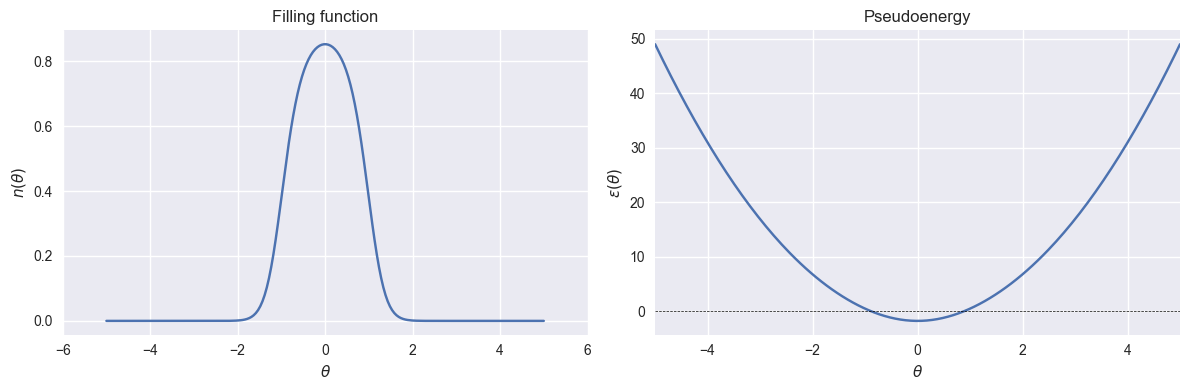

In [3]:
T = 0.5
mu = 0.5

state = TBAState.from_betas(model, grid, betas={2: 1/T, 0: -mu/T})

# plot filling function
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#plot(state.filling, ax=axes[0])
axes[0].plot(grid.points, state.filling.values)
axes[0].set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$n(\theta)$')
axes[0].set_title('Filling function')
axes[0].set_xlim(-6, 6)

# plot pseudoenergy
epsilon = np.log((1 - state.filling.values) / state.filling.values)
axes[1].plot(grid.points, epsilon)
axes[1].set_xlabel(r'$\theta$')
axes[1].set_ylabel(r'$\epsilon(\theta)$')
axes[1].set_title('Pseudoenergy')
axes[1].set_xlim(-5, 5)
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Thermodynamic quantities

From the filling function we can compute the particle density 
$\rho_p(\theta)$, the state density $\rho_s(\theta)$, and the
effective velocity $v^{eff}(\theta)$.

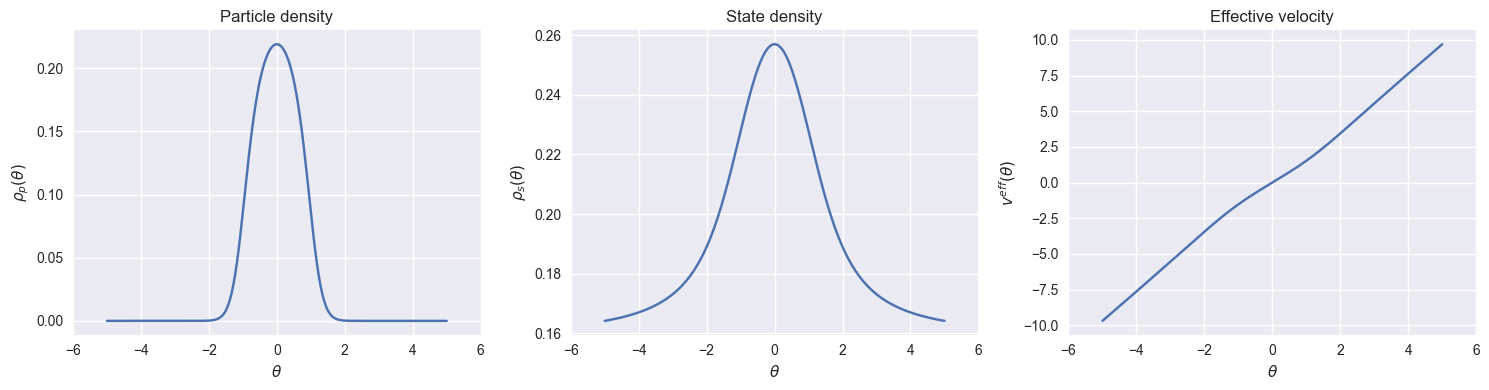

Total particle density N/L = 0.394173
Free energy density f = -0.464790


In [4]:
rho_p = state.rho_p()
rho_s = state.rho_s()
v_eff = state.v_eff()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(grid.points, rho_p.values)
axes[0].set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$\rho_p(\theta)$')
axes[0].set_title('Particle density')
axes[0].set_xlim(-6, 6)

axes[1].plot(grid.points, rho_s.values)
axes[1].set_xlabel(r'$\theta$')
axes[1].set_ylabel(r'$\rho_s(\theta)$')
axes[1].set_title('State density')
axes[1].set_xlim(-6, 6)

axes[2].plot(grid.points, v_eff.values)
axes[2].set_xlabel(r'$\theta$')
axes[2].set_ylabel(r'$v^{eff}(\theta)$')
axes[2].set_title('Effective velocity')
axes[2].set_xlim(-6, 6)

plt.tight_layout()
plt.show()

# total density
N_L = rho_p.integrate().values
print(f"Total particle density N/L = {N_L:.6f}")
print(f"Free energy density f = {state.free_energy():.6f}")

## Temperature dependence

We now vary the temperature at fixed chemical potential and observe
how the filling function evolves from the Fermi-Dirac distribution
at high temperature to a step function at zero temperature.

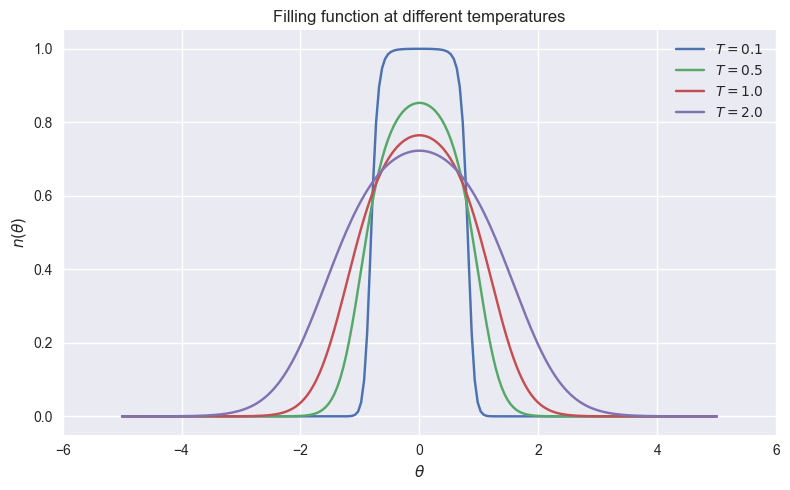

In [5]:
temperatures = [0.1, 0.5, 1.0, 2.0]
mu = 0.5

fig, ax = plt.subplots(figsize=(8, 5))

for T in temperatures:
    state = TBAState.from_betas(model, grid, betas={2: 1/T, 0: -mu/T})
    ax.plot(grid.points, state.filling.values, label=f'$T={T}$')

ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$n(\theta)$')
ax.set_title('Filling function at different temperatures')
ax.set_xlim(-6, 6)
ax.legend()
plt.tight_layout()
plt.show()

## Zero temperature limit

At zero temperature all states below the Fermi rapidity $\theta_F$ are
filled. We construct the zero temperature state directly using
`TBAState.zero_temperature`, which uses a Gauss-Legendre grid on
$[-\theta_F, \theta_F]$.

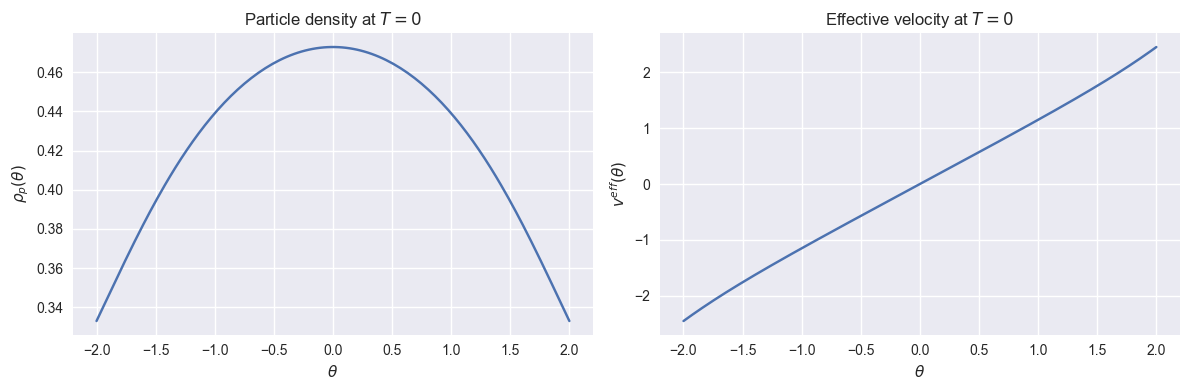

Total density N/L = 1.705870
Fermi rapidity theta_F = 2.0


In [6]:
theta_f = 2.0
state_T0 = TBAState.zero_temperature(model, theta_f=theta_f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(state_T0.grid.points, state_T0.rho_p().values)
axes[0].set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$\rho_p(\theta)$')
axes[0].set_title(r'Particle density at $T=0$')

axes[1].plot(state_T0.grid.points, state_T0.v_eff().values)
axes[1].set_xlabel(r'$\theta$')
axes[1].set_ylabel(r'$v^{eff}(\theta)$')
axes[1].set_title(r'Effective velocity at $T=0$')

plt.tight_layout()
plt.show()

N_L = state_T0.rho_p().integrate().values
print(f"Total density N/L = {N_L:.6f}")
print(f"Fermi rapidity theta_F = {theta_f}")

## Working at fixed density

In practice it is often more natural to specify the particle density
$N/L$ rather than the chemical potential. We use `find_mu` to find
the chemical potential that reproduces the target density.

In [7]:
from rapidity.thermodynamics import find_mu

target_density = 1.0
T = 0.5

mu = find_mu(model, grid, density=target_density, T=T)
state = TBAState.from_betas(model, grid, betas={2: 1/T, 0: -mu/T})

print(f"Target density: {target_density}")
print(f"Chemical potential: mu = {mu:.6f}")
print(f"Achieved density: {state.rho_p().integrate().values:.6f}")

Target density: 1.0
Chemical potential: mu = 1.472007
Achieved density: 1.000000


## References

- [YangYang1969] Yang, C. N., & Yang, C. P. (1969). Thermodynamics of a
  one-dimensional system of bosons with repulsive delta-function interaction.
  *Journal of Mathematical Physics*, 10(7), 1115-1122.

- [Takahashi1999] Takahashi, M. (1999). *Thermodynamics of One-Dimensional
  Solvable Models*. Cambridge University Press.